In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

In [46]:
wine= load_wine()

X= wine.data
y= wine.target

print('Dataset shape: ', X.shape)
print('Classes: ', list(wine.target_names))

Dataset shape:  (178, 13)
Classes:  [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [47]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [48]:
# make a pipline
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7, metric="minkowski", p=2))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [49]:
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy:  0.9777777777777777

Confusion Matrix:
 [[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



# manually k এর value change করে দেখব যে কেমন accuracy আসতেছে। তবে real dataset এ আমরা gridsearchCV, bayesian optimization এর মত hyperparameter দিয়ে best parameters গুলা বের করব

In [50]:
k_values= range(1, 42)
accs= []

for k in k_values:
    model= Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    pred= model.predict(X_test)
    accs.append(accuracy_score(y_test, y_pred))

In [51]:
print(accs)

[0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777, 0.9777777777777777]


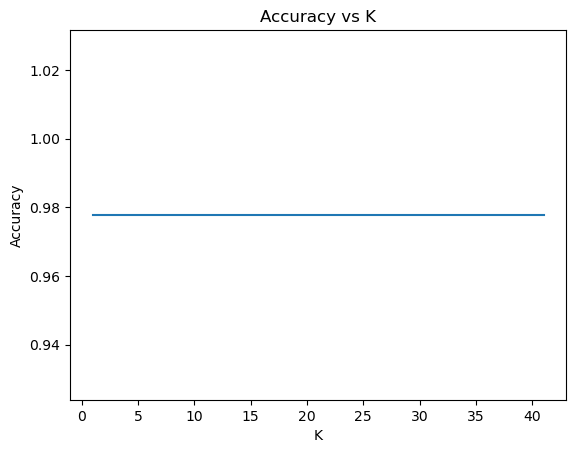

Best K:  1
Best accuracy:  0.9777777777777777


In [52]:
# plot the accs
plt.figure()
plt.plot(list(k_values), accs)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K')
plt.show()

best_k= list(k_values)[int(np.argmax(accs))]
print('Best K: ', best_k)
print('Best accuracy: ', float(np.max(accs)))